# hpDIRC starter notebook

This notebook reads data from the hpDIRC test stand and does a first, simple analysis.
Run the cells from top to bottom with **Shift+Enter**.

**What's in the data.** The detector signals are digitised by a CAEN V1742 board: **32 channels**
in **4 groups of 8**, each recording **1024 samples** at 5 GS/s (one sample every 0.2 ns,
so ~205 ns per event). Each group also records the fast trigger signal (TR0/TR1).
At the start of each run the DAQ also saves the setup: HV settings, motor position, etc.

**What the `hpdirc` module does for you.** It opens the raw `.evt` file and applies the
digitiser's calibration (`calib_0049_5G.dat`), so the waveforms you get are clean numpy arrays:

| | shape | units |
|---|---|---|
| `ev.wave` | (32, 1024) | ADC counts |
| `ev.time` | (32, 1024) | ns |
| `ev.trig` | (4, 1024) | ADC counts, trigger signal per group |

The signals are **negative-going** pulses below a baseline of roughly 2000 ADC counts.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hpdirc

# --- change these to the run you want to look at ---
DATA_FILE  = "data/test-00000068-0000.evt"
CALIB_FILE = "data/calib_0049_5G.dat" # must be specific to your run (check )

## 1. Open a run and look at the run conditions

In [58]:
run = hpdirc.Run(DATA_FILE, calib=CALIB_FILE)

print("Begin-run information stored in this file:", run.beginrun_packets())
print()
print(run.hv())
print(run.motor())
print(run.digitizer())
# print(run.setup_script()) # prints the full setup script used to configure the run

Begin-run information stored in this file: [900, 920, 921, 930, 931, 940, 941]

Tue  6 Oct 15:40:11 BST 2026
BDNAME  N1470
BDSNUM  236
BDFREL  2.03
BDCTR   REMOTE
BDILK   NO
CH     VSET     VMON     ISET     IMON      RUP      RDW     MAXV      POL     STAT  flags
 0   2100.0   2099.8  1600.00  0320.35      050      050     2300        -    00001  ON
 1   2200.0   0000.2  1600.00  0000.00      050      050     2300        -    02048  KILL
 2   2100.0   0000.0  1600.00  0000.00      050      050     2500        -    02048  KILL
 3   1250.0   0000.4  1600.00  0000.00      050      050     2500        -    02048  KILL
units: V, uA, V/s

THOR_X:read_pos                65
THOR_Y:read_pos                82

0  0 CAEN Digitizer V1742
 Firmware      04.01 - Build D408 / 00.06 - Build D409
 Serial Number 49



## 2. Look at a single event

`run.events()` gives you the events one at a time. `next(...)` takes just the first one.

run 68  event 2  samples 1024


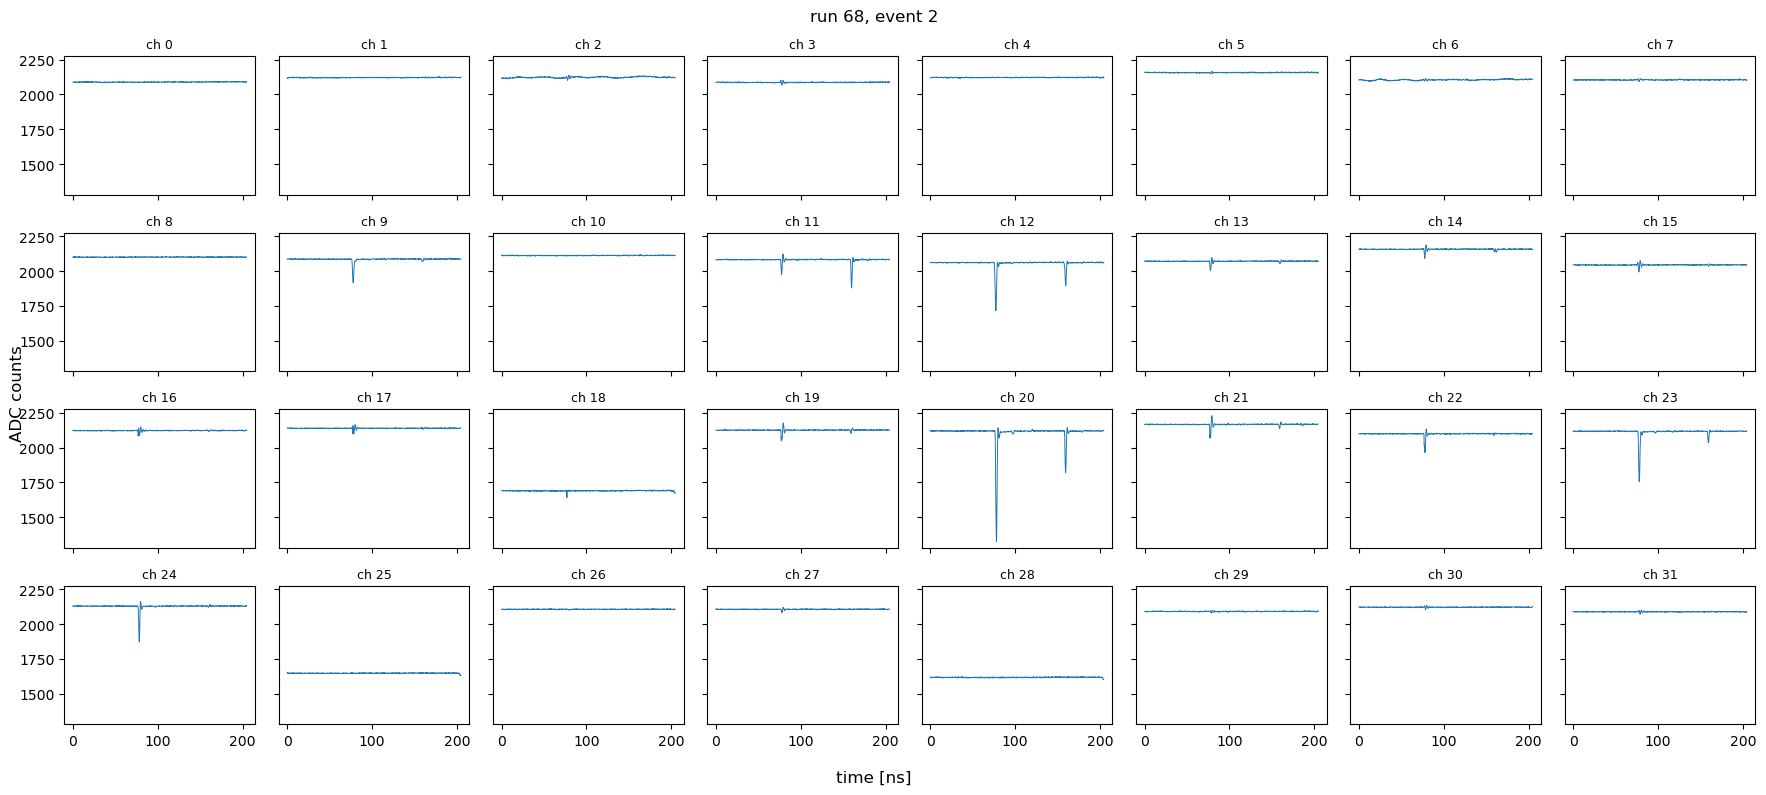

In [59]:
events = run.events()
ev = next(events)

print("run", ev.run, " event", ev.number, " samples", ev.samples)

fig, axes = plt.subplots(4, 8, figsize=(18, 8), sharex=True, sharey=True)
for ch, ax in enumerate(axes.flat):
    ax.plot(ev.time[ch], ev.wave[ch], lw=0.7)
    ax.set_title(f"ch {ch}", fontsize=9)
fig.supxlabel("time [ns]")
fig.supylabel("ADC counts")
fig.suptitle(f"run {ev.run}, event {ev.number}")
plt.tight_layout()
plt.show()

Most channels will be flat in most events - a signal only shows up in channels where a photon
was detected. Let's step through events until we find one with a clear pulse in a chosen channel,
and zoom in on it together with the trigger signal of the same group.

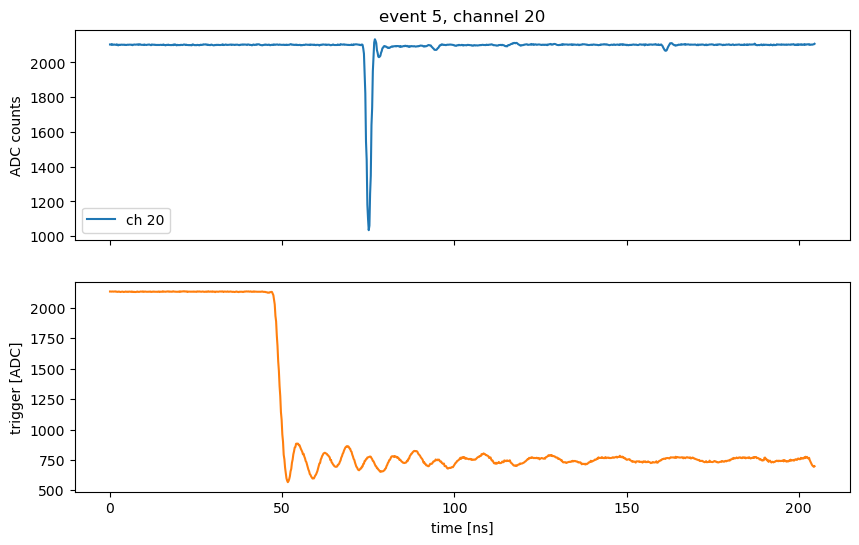

In [ ]:
CHANNEL = 20         # try other channels!
EVENT = 5            # event number to look at
THRESHOLD_TRIG = 1000      # threshold for trigger detection (in ADC counts)

run = hpdirc.Run(DATA_FILE, calib=CALIB_FILE) # reload the run to start from the beginning

for candidate in run.events(): # loop through events until we find the one we want
    if candidate.number == EVENT:
        ev = candidate
        break
else:
    raise ValueError(f"Event {EVENT} was not found")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(ev.time[CHANNEL], ev.wave[CHANNEL], label=f"ch {CHANNEL}")
ax1.set_ylabel("ADC counts")
ax1.set_title(f"event {ev.number}, channel {CHANNEL}")
ax1.legend()

group = CHANNEL // 8 # group number for this channel (they are grouped in 8s, corresponding to the 8 digitizer boards. One trigger channel per group, so the trigger waveform is the same for all channels in a group)
ax2.plot(ev.trigtime[group], ev.trig[group], color="C1")
ax2.set_ylabel("trigger [ADC]")
ax2.set_xlabel("time [ns]")
plt.show()

## 3. Loop over many events

For every event and every channel we measure three simple things and store them in a table
(a pandas DataFrame - like a spreadsheet):

* **baseline** - median of the waveform
* **amplitude** - how far the lowest point goes below the baseline
* **peak time** - when the lowest point happens (ns)

We also measure the **trigger time** of each group (when the trigger signal crosses
half-way between its baseline and its extreme), so that pulse times can be measured
*relative to the trigger*, which removes event-to-event jitter.

In [ ]:
def trigger_time(t, w):
    # Find samples where the trigger signal is low enough.
    below_threshold = w <= 1500 # try other thresholds if you want to see how it affects the trigger time

    # If the threshold was crossed
    if np.any(below_threshold):
        first_crossing = np.argmax(below_threshold)
        return t[first_crossing] # return the time of the first crossing
    
    # If no crossing was found
    return np.nan  #return NaN.

def baseline(waveform):
    # estimate the baseline of the waveform
    return 0

def corrected_waveform(waveform, baseline):
    # Subtract the baseline from the waveform to get the corrected waveform
    return 0

def amplitude(waveform):
    # Compute the lowest excursion of the signal from the baseline; this is the amplitude of the waveform
    return 1

def peak_time(time, waveform):
    # Find the index of the minimum value in the waveform
    return 1


def analyse(ev):
    rows = []
    trig_t = [trigger_time(ev.trigtime[g], ev.trig[g]) for g in range(4)]
    baseline = 1 # compute baseline to subtract from the waveform (for example, try the mean of an early part of the waveform)
    amplitude = 1 # compute lowest excursion of the signal from the baseline; this is the amplitude of the waveform
    peak_time = 1 # compute the time of the peak of the waveform (there are many ways to do this, for example, simply find the index of the minimum value, then use that index to get the corresponding time)

    for ch in range(32):
        rows.append({
            "event": ev.number,
            "channel": ch,
            "amplitude": amplitude,
            "peak_time": peak_time,
            "trigger_time": trig_t[ch // 8],
        })
    return rows

N_EVENTS = 5000      # set to None to read the whole file (can take minutes for big files)


run = hpdirc.Run(DATA_FILE, calib=CALIB_FILE)    # re-open to start from the beginning
rows = []
for ev in run.events(max_events=N_EVENTS):
    rows.extend(analyse(ev)) # for each event, analyse it and add the results to the list of rows

df = pd.DataFrame(rows) # convert the list of rows to a pandas DataFrame
df["dt"] = df["peak_time"] - df["trigger_time"] # add new columns like this to the DataFrame

df # show the dataframe

,event,channel,amplitude,peak_time,trigger_time,dt
0,2,0,1,1,53.611496,-52.611496
1,2,1,1,1,53.611496,-52.611496
2,2,2,1,1,53.611496,-52.611496
3,2,3,1,1,53.611496,-52.611496
4,2,4,1,1,53.611496,-52.611496
...,...,...,...,...,...,...
23259,728,27,1,1,46.468002,-45.468002
23260,728,28,1,1,46.468002,-45.468002
23261,728,29,1,1,46.468002,-45.468002
23262,728,30,1,1,46.468002,-45.468002


In [ ]:
# try plotting again, but this time plot a corrected (baseline subtracted) waveform for a specific channel and event


In [ ]:
# try plotting histograms of the amplitude and dt for all channels and events

## 4. Which channels see signals?

In [52]:
# Often, we want to look at how many events reach a threshold. For example, we can look at how many events have a peak amplitude below a certain threshold. This is useful for understanding the efficiency and light level of the run.
# Try implementing this for a single channel, and then for all channels. You can use the pandas DataFrame to do this easily.
 
THRESHOLD = 30

df

,event,channel,amplitude,peak_time,trigger_time,dt
0,2,0,1,1,53.611496,-52.611496
1,2,1,1,1,53.611496,-52.611496
2,2,2,1,1,53.611496,-52.611496
3,2,3,1,1,53.611496,-52.611496
4,2,4,1,1,53.611496,-52.611496
...,...,...,...,...,...,...
23259,728,27,1,1,46.468002,-45.468002
23260,728,28,1,1,46.468002,-45.468002
23261,728,29,1,1,46.468002,-45.468002
23262,728,30,1,1,46.468002,-45.468002


## 5. Amplitude and timing for one channel

In [ ]:
# you can easily filter the DataFrame to only include events that meet certain criteria. For example, to look at events for a single channel, you can do:
CHANNEL = 10
THRESHOLD = 0.1

df_filtered = df[df.channel == CHANNEL]
# you can then further filter this to only include events that have an amplitude above a certain threshold:
df_filtered_ampcut = df_filtered[df_filtered.amplitude > THRESHOLD]

# or you can combine the two filters in one line:
df_filtered_combined = df[(df.channel == CHANNEL) & (df.amplitude > THRESHOLD)]

df_filtered_combined # show the filtered dataframe

,event,channel,amplitude,peak_time,trigger_time,dt
10,2,10,1,1,53.732201,-52.732201
42,3,10,1,1,52.473892,-51.473892
74,4,10,1,1,52.444695,-51.444695
106,5,10,1,1,50.704002,-49.704002
138,6,10,1,1,50.377098,-49.377098
...,...,...,...,...,...,...
23114,724,10,1,1,51.556202,-50.556202
23146,725,10,1,1,50.619827,-49.619827
23178,726,10,1,1,49.727005,-48.727005
23210,727,10,1,1,49.482590,-48.482590


## 6. Save your results

Saving the table means you don't have to re-read the raw data next time.

In [48]:
df.to_csv("results.csv", index=False)
# later:  df = pd.read_csv("results.csv")

## Things to try

1. Complete the missing functions and try adding a baseline correction to the waveform plots.
2. Make some plots of `CHANNEL` and add a `THRESHOLD` line. Where is the noise level, where are the real pulses?
   Make a histogram of the **baseline** - is it the same in every channel?
3. A index based peak **time** is only as good as one sample (0.2 ns). 
   Improve it: 
      - try a threshold crossing method
      - try a constant fraction timing method
      - add interpolation between samples
3. Instead of the amplitude, compute the **charge**: the area below the baseline in a
   window around the peak. Plot the charge spectrum - can you see single photo-electrons?
4. Compare runs taken at different HV (look at `run.hv()`) or motor positions (`run.motor()`).
   How do the hit rate and amplitude change?
5. Look at events with signals in **several** channels at once. How are their times correlated?

**Help:** `help(hpdirc.Run)`. To see the waveforms without the DRS4 spike removal,
open the run with `hpdirc.Run(DATA_FILE, calib=CALIB_FILE, despike=False)` and look at
channels with no signal - you'll see the narrow spikes this step removes.